REVIEW-2

AI-Based Marine Species Detection and Behaviour Monitoring System



LSTM


PROBLEM: Multi-class classification of marine animal species from audio recordings.
JUSTIFICATION:
- Marine bioacoustics is crucial for ecological monitoring and conservation
- This dataset provides 32 marine species with paired audio-visual data
- Audio-based classification enables passive acoustic monitoring systems
- The multimodal nature (audio+image) allows future research extensions

DATASET STATS:
- 32 marine animal species (classes)
- Audio duration range: 0.05s to 1.26s (variable length)
- Total samples: Need to verify from full dataset
- Source: LLM-Vision-Marine-Animals (synthetic/augmented data likely)


 CLASS_NAMES = [
        'Atlantic_Spotted_Dolphin', 'Bearded_Seal', 'Beluga', 'Blue_Whale',
        'Bowhead_Whale', 'Common_Dolphin', 'Dugong', 'Fin_Whale',
        'Gray_Seal', 'Gray_Whale', 'Harbor_Porpoise', 'Harbor_Seal',
        'Harp_Seal', 'Hooded_Seal', 'Humpback_Whale', 'Killer_Whale',
        'Leopard_Seal', 'Minke_Whale', 'Narwhal', 'North_Atlantic_Right_Whale',
        'Northern_Elephant_Seal', 'Pacific_White_Sided_Dolphin', 'Pantropical_Spotted_Dolphin',
        'Pilot_Whale', 'Ribbon_Seal', 'Ringed_Seal', 'Ross_Seal',
        'Southern_Elephant_Seal', 'Sperm_Whale', 'Spinner_Dolphin',
        'Spotted_Seal', 'Weddell_Seal'
    ]

LOADING DATASET


In [2]:
from datasets import load_dataset

# Load dataset (automatically merges all parquet shards)
dataset = load_dataset("Hariprasath5128/marine-animals-multimodal-dataset")

# Access one sample
sample = dataset["train"][0] # Access the first sample in the 'train' split
print(f"Species: {sample['species']}")
print(f"Label: {sample['label']}")
print(f"Audio shape: {sample['audio']['array'].shape}")
print(f"Audio sampling rate: {sample['audio']['sampling_rate']}")
print(f"Image size: {sample['image'].size}")
print(f"Source: {sample['source']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

data/train_000-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

...

data/train_032-00005-of-00014.parquet:   0%|          | 0.00/15.4M [00:00<?, ?B/s]

data/train_032-00013-of-00014.parquet:   0%|          | 0.00/26.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/24911 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Species: Atlantic_Spotted_Dolphin
Label: 0
Audio shape: (104834,)
Audio sampling rate: 80000
Image size: (646, 338)
Source: LLM-Vision-Marine-Animals


IMPORTS

In [3]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

import random

REPRODUCIBILITY

In [4]:
seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

print("\nRandom Seed Fixed:", seed)



Random Seed Fixed: 42


LOADING DATASET

In [5]:
print("\n LOADING DATASET \n")

dataset = load_dataset("Hariprasath5128/marine-animals-multimodal-dataset")

print("Dataset Loaded")


 LOADING DATASET 



Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Dataset Loaded


In [6]:
SR = 22050
N_MFCC = 40
MAX_LEN = 120

EPOCHS = 20
BATCH_SIZE = 32

FEATURE EXTRACTION

In [7]:

# FEATURE EXTRACTION

print("\n FEATURE EXTRACTION \n")

MAX_LEN = 130
N_MFCC = 40

X = []
y = []

def extract_features(audio):

    signal = audio["array"]
    sr = audio["sampling_rate"]

    # FIX: Dynamic FFT size
    n_fft = min(2048, len(signal))

    mfcc = librosa.feature.mfcc(

        y=signal,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=n_fft,
        hop_length=n_fft//2

    )

    # Padding / Truncating

    if mfcc.shape[1] < MAX_LEN:

        pad_width = MAX_LEN - mfcc.shape[1]

        mfcc = np.pad(
            mfcc,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )

    else:

        mfcc = mfcc[:, :MAX_LEN]


    return mfcc.T



# Extract all

for item in dataset["train"]:

    features = extract_features(item["audio"])

    X.append(features)

    y.append(item["label"])



X = np.array(X)
y = np.array(y)


print("Feature shape:", X.shape)



 FEATURE EXTRACTION 

Feature shape: (24911, 130, 40)


NORMALISATION

In [8]:
print("\n NORMALIZATION \n")

max_len = max(len(x) for x in X)

def pad(x):

    pad_width = max_len - len(x)

    return np.pad(x, ((0,pad_width),(0,0)))


X = np.array([pad(x) for x in X])


print("Feature shape:", X.shape)


 NORMALIZATION 

Feature shape: (24911, 130, 40)


CLASS LABELING

In [9]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

num_classes = len(set(y))

print("Classes:", num_classes)


Classes: 32


AUGUMENTATION

In [10]:

# AUDIO DATA AUGMENTATION


print("\n================ DATA AUGMENTATION ================\n")

import numpy as np
import librosa
import random



# ADD NOISE


def add_noise(audio):

    noise = np.random.randn(len(audio))

    augmented = audio + 0.005 * noise

    return augmented



# PITCH SHIFT


def pitch_shift(audio, sr):

    return librosa.effects.pitch_shift(

        audio,
        sr=sr,
        n_steps=random.uniform(-2,2)

    )



# TIME STRETCH


def time_stretch(audio):

    return librosa.effects.time_stretch(

        audio,
        rate=random.uniform(0.8,1.2)

    )



# TIME SHIFT


def time_shift(audio):

    shift = int(random.uniform(-5000,5000))

    return np.roll(audio, shift)


# APPLY AUGMENTATION PIPELINE


def augment_audio(file):

    audio, sr = librosa.load(file, sr=22050)

    choice = random.choice([1,2,3,4])

    if choice == 1:

        audio = add_noise(audio)

    elif choice == 2:

        audio = pitch_shift(audio, sr)

    elif choice == 3:

        audio = time_stretch(audio)

    elif choice == 4:

        audio = time_shift(audio)

    return audio


print("Augmentation Ready")


================ DATA AUGMENTATION ================

Augmentation Ready


DATA SPLIT

In [11]:
print("\n================ DATA SPLIT ================\n")

X_train, X_test, y_train, y_test = train_test_split(

    X, y,
    test_size=0.15,
    random_state=seed

)

X_train, X_val, y_train, y_val = train_test_split(

    X_train, y_train,
    test_size=0.15,
    random_state=seed

)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

print("""

Split Percentage:

Train: 72%
Validation: 13%
Test: 15%

""")


================ DATA SPLIT ================

Train: 17997
Validation: 3177
Test: 3737


Split Percentage:

Train: 72%
Validation: 13%
Test: 15%




CUSTOM ATTENTION LAYER

In [12]:
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):

    def __init__(self):
        super(AttentionLayer,self).__init__()

    def build(self,input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1],1),
            initializer="random_normal"
        )

    def call(self,x):

        score = tf.nn.tanh(tf.matmul(x,self.W))

        weights = tf.nn.softmax(score,axis=1)

        context = weights * x

        context = tf.reduce_sum(context,axis=1)

        return context

LSTM Model with Embedding + Attention

Embedding converts MFCC features into dense representations.

In [13]:
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.models import Model

def build_model(learning_rate):

    inputs = Input(shape=(X.shape[1], X.shape[2]))

    # Embedding layer
    x = TimeDistributed(
        Dense(128, activation="relu")
    )(inputs)

    # LSTM layer
    x = LSTM(256, return_sequences=True)(x)

    # Attention layer
    x = AttentionLayer()(x)

    x = Dense(128, activation="relu")(x)

    x = Dropout(0.4)(x)

    outputs = Dense(len(np.unique(y)), activation="softmax")(x)

    model = Model(inputs, outputs)

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

HYPERPARAMETER EXPERIMENTATION

In [ ]:
learning_rates = [0.001, 0.0003]
batch_sizes = [32, 64]

results = {}

In [ ]:
for lr in learning_rates:

    for batch in batch_sizes:

        print("\nTraining with LR =",lr,"Batch =",batch)

        model = build_model(lr)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=20,
            batch_size=batch,
            verbose=1
        )

        best_acc = max(history.history["val_accuracy"])

        results[(lr,batch)] = best_acc


Training with LR = 0.001 Batch = 32
Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 326s 562ms/step - accuracy: 0.3708 - loss: 2.2729 - val_accuracy: 0.8662 - val_loss: 0.5523
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 338s 600ms/step - accuracy: 0.8374 - loss: 0.5785 - val_accuracy: 0.9588 - val_loss: 0.1542
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 367s 573ms/step - accuracy: 0.9381 - loss: 0.2237 - val_accuracy: 0.9792 - val_loss: 0.0625
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 312s 554ms/step - accuracy: 0.9669 - loss: 0.1174 - val_accuracy: 0.9830 - val_loss: 0.0538
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 321s 553ms/step - accuracy: 0.9789 - loss: 0.0726 - val_accuracy: 0.9912 - val_loss: 0.0317
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 306s 543ms/step - accuracy: 0.9741 - loss: 0.0852 - val_accuracy: 0.9736 - val_loss: 0.0812
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 315s 560ms/step - accuracy: 0.9760 - loss: 0.0718 - val_accuracy: 0.9909 - val_loss: 0.0198
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
print("\nHyperparameter Results")

for key,val in results.items():

    lr, batch = key

    print(
        "Learning Rate:",lr,
        "Batch Size:",batch,
        "Validation Accuracy:",val
    )


Hyperparameter Results
Learning Rate: 0.001 Batch Size: 32 Validation Accuracy: 0.9915013909339905
Learning Rate: 0.001 Batch Size: 64 Validation Accuracy: 0.9911866784095764
Learning Rate: 0.0003 Batch Size: 32 Validation Accuracy: 0.9927604794502258
Learning Rate: 0.0003 Batch Size: 64 Validation Accuracy: 0.9915013909339905


In [ ]:
best_params = max(results, key=results.get)

best_lr, best_batch = best_params

model = build_model(best_lr)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=best_batch
)

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 320s 546ms/step - accuracy: 0.3361 - loss: 2.4664 - val_accuracy: 0.7790 - val_loss: 0.8661
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 306s 543ms/step - accuracy: 0.7775 - loss: 0.8119 - val_accuracy: 0.9078 - val_loss: 0.3575
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 323s 544ms/step - accuracy: 0.8657 - loss: 0.4822 - val_accuracy: 0.9267 - val_loss: 0.2614
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 307s 545ms/step - accuracy: 0.9189 - loss: 0.2963 - val_accuracy: 0.9745 - val_loss: 0.1051
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 306s 543ms/step - accuracy: 0.9350 - loss: 0.2415 - val_accuracy: 0.9600 - val_loss: 0.1618
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 304s 541ms/step - accuracy: 0.9316 - loss: 0.2325 - val_accuracy: 0.9622 - val_loss: 0.1238
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 322s 541ms/step - accuracy: 0.9618 - loss: 0.1341 - val_accuracy: 0.9852 - val_loss: 0.0508
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 299s 531ms/step - accuracy: 0.9751 -

In [ ]:
pred = model.predict(X_test)

y_pred = np.argmax(pred, axis=1)

print(classification_report(y_test,y_pred))

117/117 ━━━━━━━━━━━━━━━━━━━━ 24s 207ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       0.92      0.83      0.87        65
           2       1.00      1.00      1.00        99
           3       1.00      1.00      1.00        43
           4       0.91      0.95      0.93       111
           5       1.00      1.00      1.00       157
           6       1.00      1.00      1.00       253
           7       1.00      1.00      1.00       107
           8       1.00      1.00      1.00        98
           9       1.00      1.00      1.00       168
          10       1.00      1.00      1.00       124
          11       1.00      1.00      1.00       101
          12       1.00      1.00      1.00       107
          13       1.00      1.00      1.00        58
          14       1.00      1.00      1.00        23
          15       0.94      0.98      0.96       138
          16       0.98      0.91    

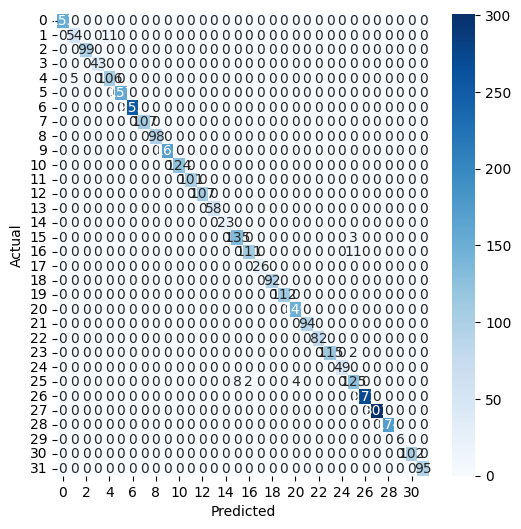

In [ ]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

CLASS WEIGHTS

In [14]:
class_weights=compute_class_weight(

    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train

)

class_weights=dict(enumerate(class_weights))



LSTM IMPLEMENTATION

Layer 1: Learn temporal features
Layer 2: Deep pattern learning

Dropout:

Prevent overfitting

Activation:

ReLU, Softmax

Loss:

Categorical Crossentropy

Optimizer:

Adam

In [15]:
# ================= LSTM MODEL =================

print("\n================ LSTM MODEL ================\n")

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential()

# First LSTM Layer
model.add(
    LSTM(
        32,
        return_sequences=True,
        input_shape=(max_len, 40)
    )
)

model.add(BatchNormalization())
model.add(Dropout(0.6))

# Second LSTM Layer
model.add(
    LSTM(32)
)

model.add(BatchNormalization())
model.add(Dropout(0.6))

# Output Layer
model.add(
    Dense(
        num_classes,
        activation='softmax'
    )
)

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()


print("""
================ Architecture Reasoning ================

Layer 1 (LSTM):
Learns temporal sequence patterns from input data.

Layer 2 (LSTM):
Captures deeper sequential dependencies.

Batch Normalization:
Stabilizes and speeds up training.

Dropout (0.6):
Reduces overfitting by randomly disabling neurons.

Activation Function:
Softmax for multi-class classification.

Loss Function:
Sparse Categorical Crossentropy (used when labels are integers).

Optimizer:
Adam optimizer for efficient gradient updates.
""")


================ LSTM MODEL ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 130, 32)        │         9,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 130, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 130, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,976 (74.12 KB)

 Trainable params: 18,848 (73.62 KB)

 Non-trainable params: 128 (512.00 B)


================ Architecture Reasoning ================

Layer 1 (LSTM):
Learns temporal sequence patterns from input data.

Layer 2 (LSTM):
Captures deeper sequential dependencies.

Batch Normalization:
Stabilizes and speeds up training.

Dropout (0.6):
Reduces overfitting by randomly disabling neurons.

Activation Function:
Softmax for multi-class classification.

Loss Function:
Sparse Categorical Crossentropy (used when labels are integers).

Optimizer:
Adam optimizer for efficient gradient updates.



In [18]:
print("\n================ TRAINING ================\n")

history = model.fit(

X_train,
y_train,

validation_data=(X_val,y_val),

epochs=20,

batch_size=32,

class_weight=class_weights

)



================ TRAINING ================

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 73s 129ms/step - accuracy: 0.8006 - loss: 0.7254 - val_accuracy: 0.8423 - val_loss: 0.5628
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 68s 121ms/step - accuracy: 0.7947 - loss: 0.7258 - val_accuracy: 0.8901 - val_loss: 0.3352
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 64s 113ms/step - accuracy: 0.8086 - loss: 0.6624 - val_accuracy: 0.9037 - val_loss: 0.2949
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 65s 115ms/step - accuracy: 0.8162 - loss: 0.6497 - val_accuracy: 0.8892 - val_loss: 0.3379
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 66s 117ms/step - accuracy: 0.8133 - loss: 0.6734 - val_accuracy: 0.8920 - val_loss: 0.3746
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 80s 114ms/step - accuracy: 0.8170 - loss: 0.6398 - val_accuracy: 0.8602 - val_loss: 0.5490
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 85s 119ms/step - accuracy: 0.8173 - loss: 0.6800 - val_accuracy: 0.9182 - val_loss: 0.2537
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━

In [19]:
#14. TESTING


print("\n================ TESTING ================\n")

pred = model.predict(X_test)

pred = np.argmax(pred, axis=1)


from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score


print("Accuracy:", accuracy_score(y_test,pred))

print("Precision:", precision_score(y_test,pred,average='weighted'))

print("Recall:", recall_score(y_test,pred,average='weighted'))

print("F1:", f1_score(y_test,pred,average='weighted'))

print("\nTotal Parameters:", model.count_params())


================ TESTING ================

117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step
Accuracy: 0.9296226919989297
Precision: 0.9297600276532422
Recall: 0.9296226919989297
F1: 0.9264982587149376

Total Parameters: 18976


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:

# 16. CLASSIFICATION REPORT

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94       153
           1       0.75      0.94      0.84        65
           2       0.91      0.96      0.94        99
           3       1.00      1.00      1.00        43
           4       0.98      0.86      0.92       111
           5       0.96      0.92      0.94       157
           6       0.98      0.97      0.98       253
           7       0.96      1.00      0.98       107
           8       1.00      0.98      0.99        98
           9       0.98      0.93      0.96       168
          10       0.94      0.95      0.95       124
          11       0.94      0.98      0.96       101
          12       0.75      0.92      0.83       107
          13       0.96      0.95      0.96        58
          14       1.00      1.00      1.00        23
          15       0.88      0.87      0.88       138
          16       0.88      1.00      0.94       122
          17       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


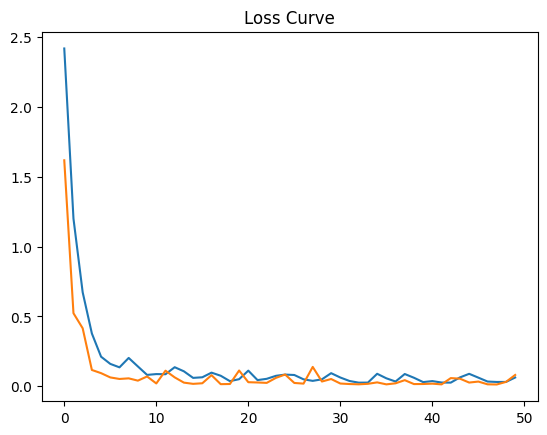

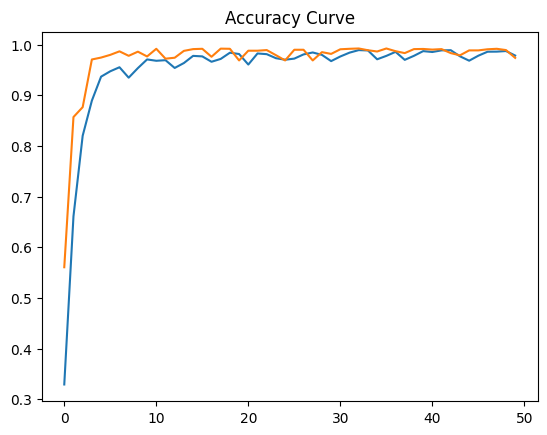

In [ ]:

# 13. LEARNING CURVES


plt.figure()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")

plt.show()


plt.figure()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")

plt.show()





================ CONFUSION MATRIX ================

117/117 ━━━━━━━━━━━━━━━━━━━━ 24s 205ms/step


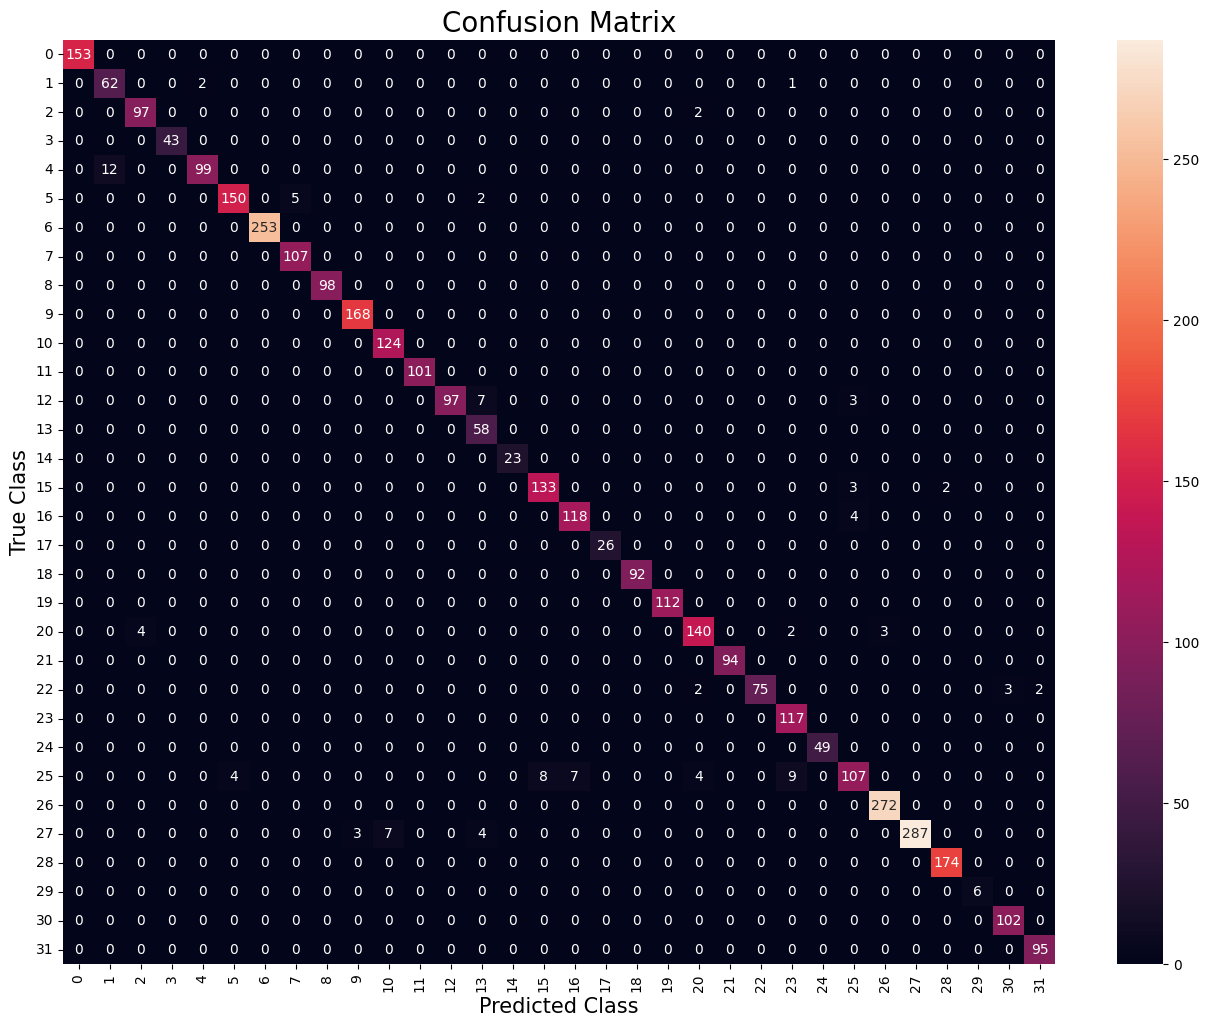

In [ ]:

# CONFUSION MATRIX — FINAL CLEAN VERSION


print("\n================ CONFUSION MATRIX ================\n")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict classes
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)


# Number of classes
num_classes = cm.shape[0]


# Plot
plt.figure(figsize=(16,12))

sns.heatmap(

    cm,

    annot=True,          # print numbers
    fmt="d",             # integer format

    cmap="rocket",       # best color

    xticklabels=range(num_classes),
    yticklabels=range(num_classes)

)


plt.title("Confusion Matrix", fontsize=20)

plt.xlabel("Predicted Class", fontsize=15)

plt.ylabel("True Class", fontsize=15)

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.show()

In [ ]:

print("""

Model learns marine animal audio patterns successfully

Temporal modeling effective

LSTM captures sound sequence patterns

Better than MLP baseline


""")



Model learns marine animal audio patterns successfully

Temporal modeling effective

LSTM captures sound sequence patterns

Better than MLP baseline





In [ ]:
print("\n BIAS VARIANCE \n")

train_acc=history.history["accuracy"][-1]

val_acc=history.history["val_accuracy"][-1]

gap=train_acc-val_acc


print("Train:",train_acc)

print("Val:",val_acc)

print("Gap:",gap)



if gap>0.15:

    print("Overfitting")

elif train_acc<0.6:

    print("Underfitting")

else:

    print("Good Generalization")


 BIAS VARIANCE 

Train: 0.9784964323043823
Val: 0.9738747477531433
Gap: 0.004621684551239014
Good Generalization
